In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import scipy.sparse as sp

adatas = {}

samples = {
    "Patient3Plate3" :"/Users/poorvivijay/GSE138262_RAW/GSM4103895_Patient3Plate3.TranscriptCounts.tsv",
    "Patient2Plate4" :"/Users/poorvivijay/GSE138262_RAW/GSM4103892_Patient2Plate4.TranscriptCounts.tsv",
    "Patient4Plate1" :"/Users/poorvivijay/GSE138262_RAW/GSM4103897_Patient4Plate1.TranscriptCounts.tsv",
    "Patient1Plate3" :"/Users/poorvivijay/GSE138262_RAW/GSM4103887_Patient1Plate3.TranscriptCounts.tsv",
    "Patient1Plate1" :"/Users/poorvivijay/GSE138262_RAW/GSM4103885_Patient1Plate1.TranscriptCounts.tsv",
    "Patient2Plate2" :"/Users/poorvivijay/GSE138262_RAW/GSM4103890_Patient2Plate2.TranscriptCounts.tsv",
    "Patient3Plate4" :"/Users/poorvivijay/GSE138262_RAW/GSM4103896_Patient3Plate4.TranscriptCounts.tsv",
    "Patient2Plate3" :"/Users/poorvivijay/GSE138262_RAW/GSM4103891_Patient2Plate3.TranscriptCounts.tsv",
    "Patient1Plate2" :"/Users/poorvivijay/GSE138262_RAW/GSM4103886_Patient1Plate2.TranscriptCounts.tsv",
    "Patient5Plate1" :"/Users/poorvivijay/GSE138262_RAW/GSM4762107_Patient5Plate1.TranscriptCounts.tsv",
    "Patient2Plate1" :"/Users/poorvivijay/GSE138262_RAW/GSM4103889_Patient2Plate1.TranscriptCounts.tsv",
    "Patient3Plate2" :"/Users/poorvivijay/GSE138262_RAW/GSM4103894_Patient3Plate2.TranscriptCounts.tsv",
    "Patient4Plate2" :"/Users/poorvivijay/GSE138262_RAW/GSM4103898_Patient4Plate2.TranscriptCounts.tsv",
    "Patient3Plate1" :"/Users/poorvivijay/GSE138262_RAW/GSM4103893_Patient3Plate1.TranscriptCounts.tsv",
    "Patient1Plate4" :"/Users/poorvivijay/GSE138262_RAW/GSM4103888_Patient1Plate4.TranscriptCounts.tsv",
    "Patient5Plate2" :"/Users/poorvivijay/GSE138262_RAW/GSM4762108_Patient5Plate2.TranscriptCounts.tsv",
}

for sample_id, path in samples.items():
    # Load with pandas
    df = pd.read_csv(path, sep='\t', index_col=0)  # GENEID is now index

    # Transpose to cells as rows, genes as columns
    df = df.T

    # Convert to AnnData
    adata_sample = sc.AnnData(df)

    # Store original gene IDs
    adata_sample.var["original_id"] = adata_sample.var.index

    # Clean gene names: drop chromosome info
    adata_sample.var_names = adata_sample.var["original_id"].str.split("__").str[0]
    adata_sample.var_names_make_unique()

    # Assign sample label
    adata_sample.obs["Sample"] = sample_id

    # Save sparse version to save RAM
    adata_sample.X = sp.csr_matrix(adata_sample.X)

    adatas[sample_id] = adata_sample

# Concatenate all samples
adata = ad.concat(adatas, label="Sample")
adata.obs_names_make_unique()

# Summary
print(adata)
print(adata.obs["Sample"].value_counts())
print(adata.var.head())


AnnData object with n_obs × n_vars = 6144 × 8200
    obs: 'Sample'
Sample
Patient3Plate3    384
Patient2Plate4    384
Patient4Plate1    384
Patient1Plate3    384
Patient1Plate1    384
Patient2Plate2    384
Patient3Plate4    384
Patient2Plate3    384
Patient1Plate2    384
Patient5Plate1    384
Patient2Plate1    384
Patient3Plate2    384
Patient4Plate2    384
Patient3Plate1    384
Patient1Plate4    384
Patient5Plate2    384
Name: count, dtype: int64
Empty DataFrame
Columns: []
Index: [A2M, A4GALT, AAAS, AACS, AAGAB]


/opt/anaconda3/lib/python3.13/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [10]:
adata.obs.head(10)

,Sample
001,Patient3Plate3
002,Patient3Plate3
003,Patient3Plate3
004,Patient3Plate3
005,Patient3Plate3
006,Patient3Plate3
007,Patient3Plate3
008,Patient3Plate3
009,Patient3Plate3
010,Patient3Plate3


In [3]:
import logging

import anndata2ri
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
import scanpy as sc
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.sparse import issparse



/opt/anaconda3/lib/python3.13/site-packages/rpy2/rinterface/__init__.py:1211: UserWarning: Environment variable "R_SESSION_TMPDIR" redefined by R and overriding existing variable. Current: "/var/folders/ms/hh2_gqcs7q9c137x_ppc1tbw0000gn/T//RtmpeX9Jyt", R: "/var/folders/ms/hh2_gqcs7q9c137x_ppc1tbw0000gn/T//RtmpPWISbL"
  warnings.warn(


In [4]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)
adata

AnnData object with n_obs × n_vars = 6144 × 8200
    obs: 'Sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [5]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

In [6]:
adata.var

,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
original_id,,,,,,,,,
A2M,False,False,False,1000,0.311507,0.271177,83.723958,1913.896726,7.557419
A4GALT,False,False,False,390,0.079591,0.076582,93.652344,489.005006,6.194416
AAAS,False,False,False,255,0.056480,0.054943,95.849609,347.014274,5.852243
AACS,False,False,False,83,0.014486,0.014382,98.649089,89.000366,4.499814
AAGAB,False,False,False,146,0.027832,0.027452,97.623698,171.001587,5.147504
...,...,...,...,...,...,...,...,...,...
ZWILCH,False,False,False,39,0.007324,0.007298,99.365234,45.000366,3.828649
ZXDC,False,False,False,301,0.079110,0.076137,95.100911,486.054432,6.188376
ZYG11B,False,False,False,938,0.263543,0.233920,84.733073,1619.209828,7.390311


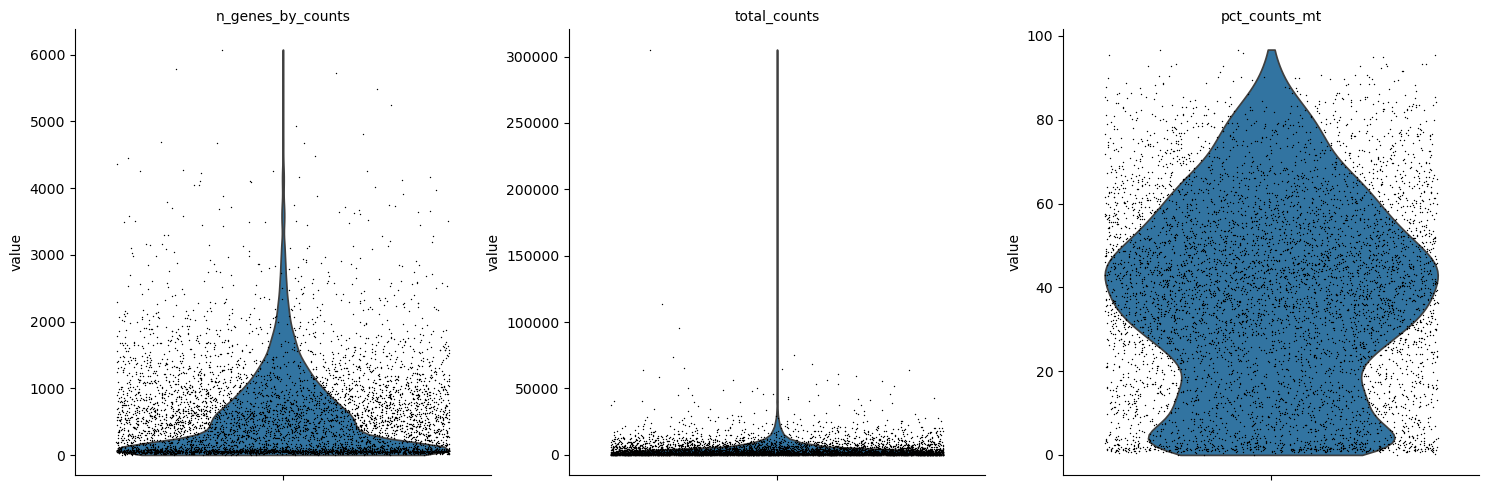

In [7]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

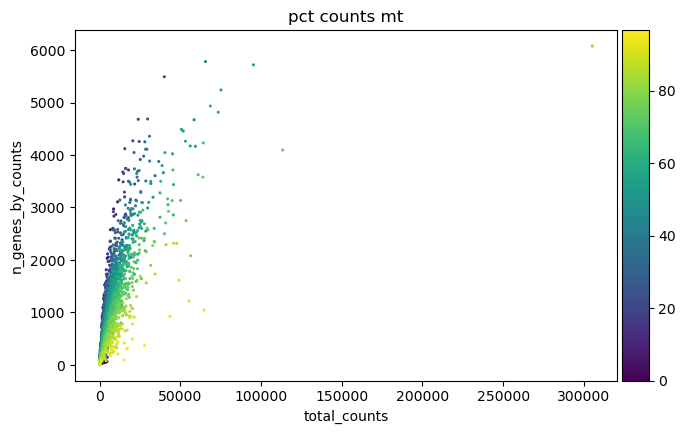

In [8]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [76]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [9]:
sc.pp.scrublet(adata, batch_key="Sample") #.... my kernel keeps dying when i run this what the heck???

In [10]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [11]:
adata

AnnData object with n_obs × n_vars = 4168 × 8200
    obs: 'Sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'scrublet'
    layers: 'counts'

In [12]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

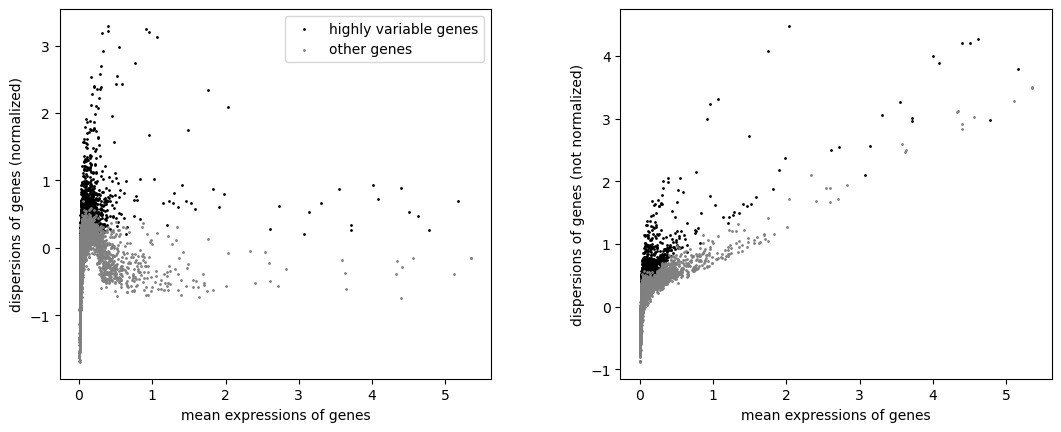

In [13]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="Sample")
sc.pl.highly_variable_genes(adata)

In [14]:
sc.tl.pca(adata)

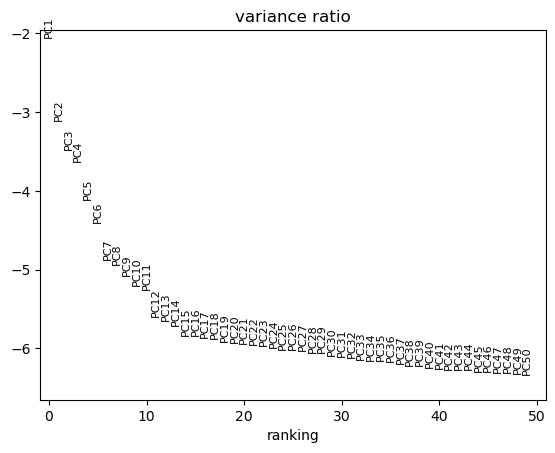

In [15]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

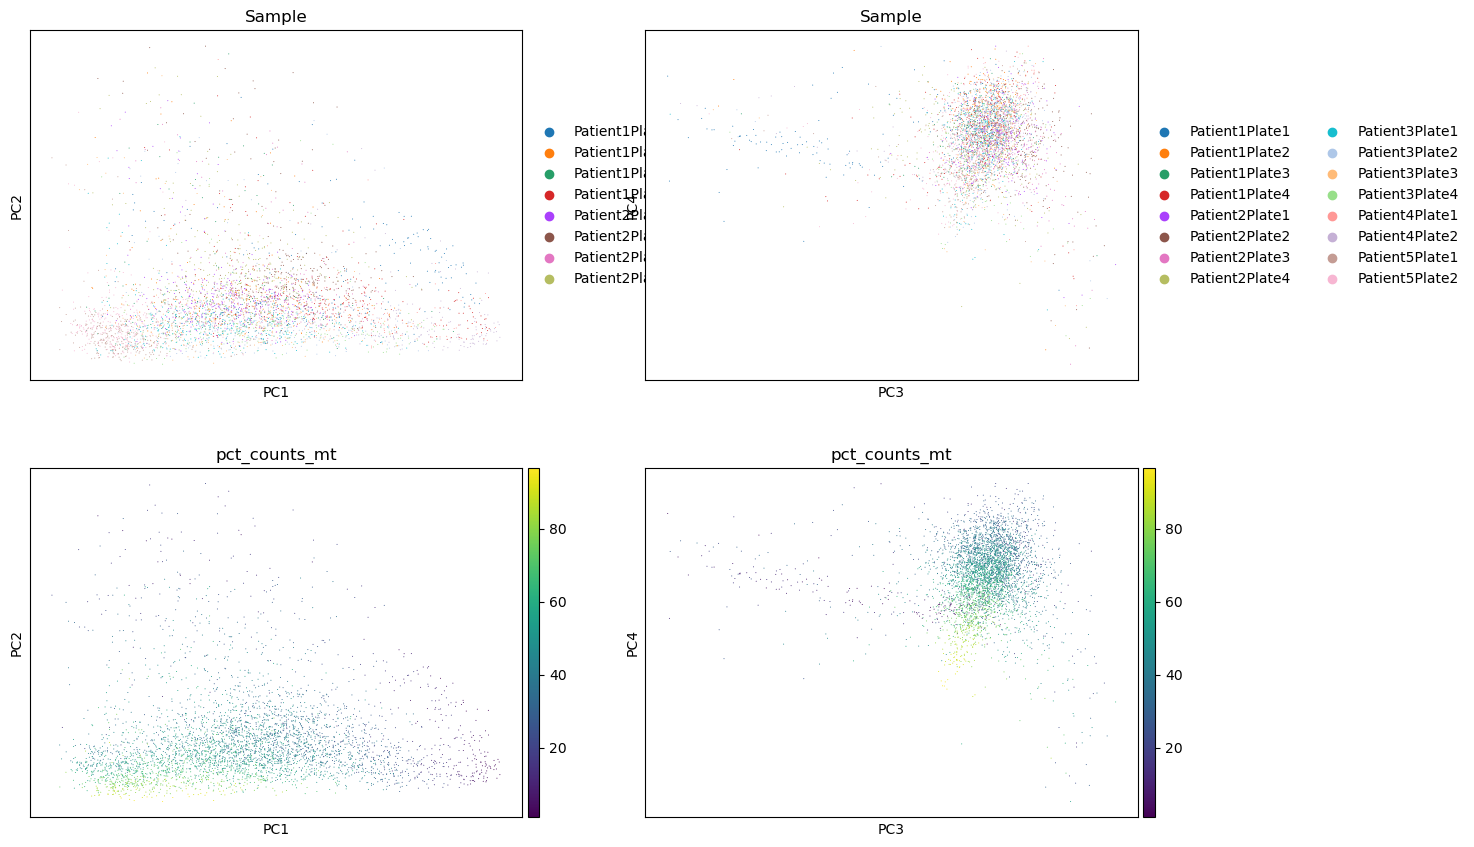

In [16]:
sc.pl.pca(
    adata,
    color=["Sample", "Sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

In [17]:
sc.pp.neighbors(adata)

In [18]:
sc.tl.umap(adata)

In [19]:
adata.obs["Sample"].value_counts()

Sample
Patient2Plate4    367
Patient5Plate2    336
Patient3Plate2    308
Patient3Plate1    302
Patient2Plate2    300
Patient2Plate1    299
Patient5Plate1    289
Patient2Plate3    282
Patient3Plate3    281
Patient1Plate4    258
Patient1Plate1    250
Patient3Plate4    231
Patient4Plate2    200
Patient1Plate2    171
Patient1Plate3    171
Patient4Plate1    123
Name: count, dtype: int64

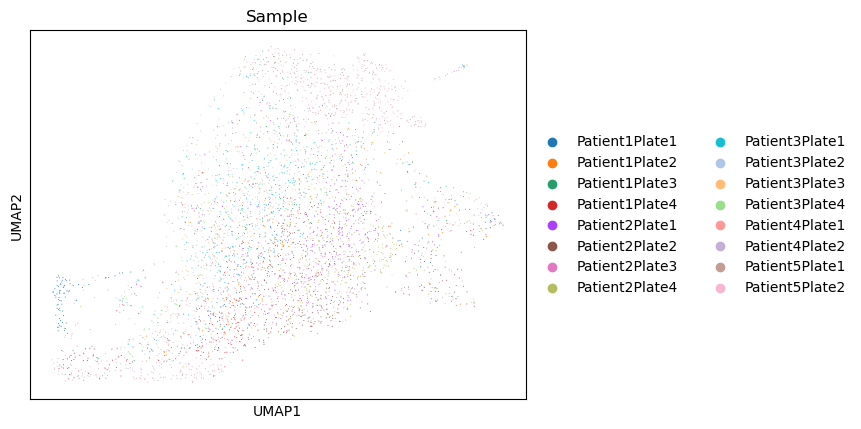

In [20]:
sc.pl.umap(
    adata,
    color="Sample",
    # Setting a smaller point size to get prevent overlap
    size=2,
)

In [21]:
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

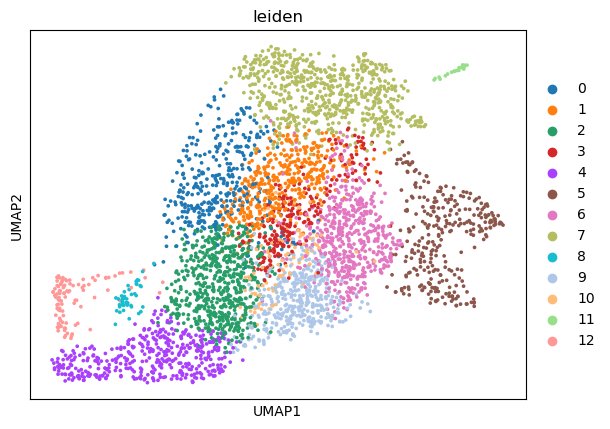

In [22]:
sc.pl.umap(adata, color=["leiden"])

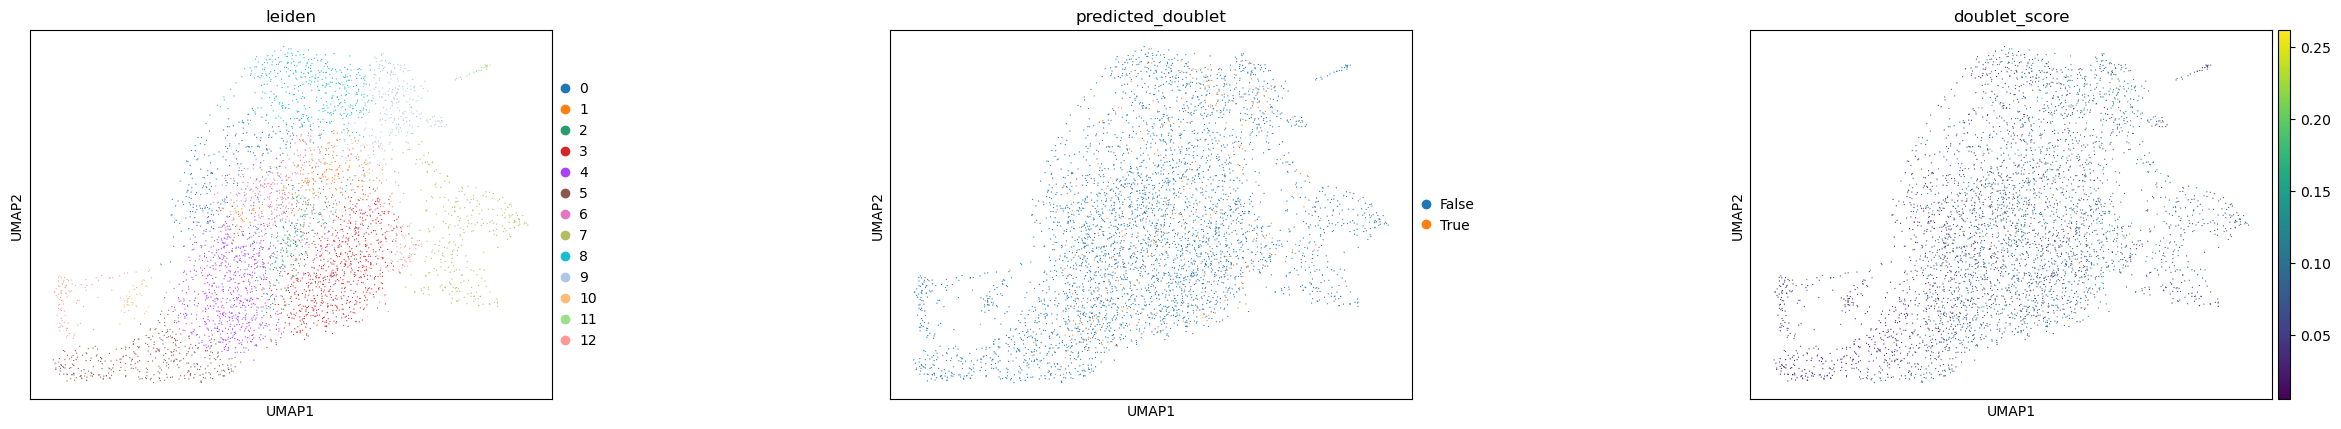

In [91]:
sc.pl.umap(
    adata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
    size=3,
)

In [93]:
adata = adata[adata.obs['pct_counts_mt'] < 25]

In [95]:
adata

View of AnnData object with n_obs × n_vars = 549 × 8200
    obs: 'Sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'Sample_colors', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'predicted_doublet_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    lay

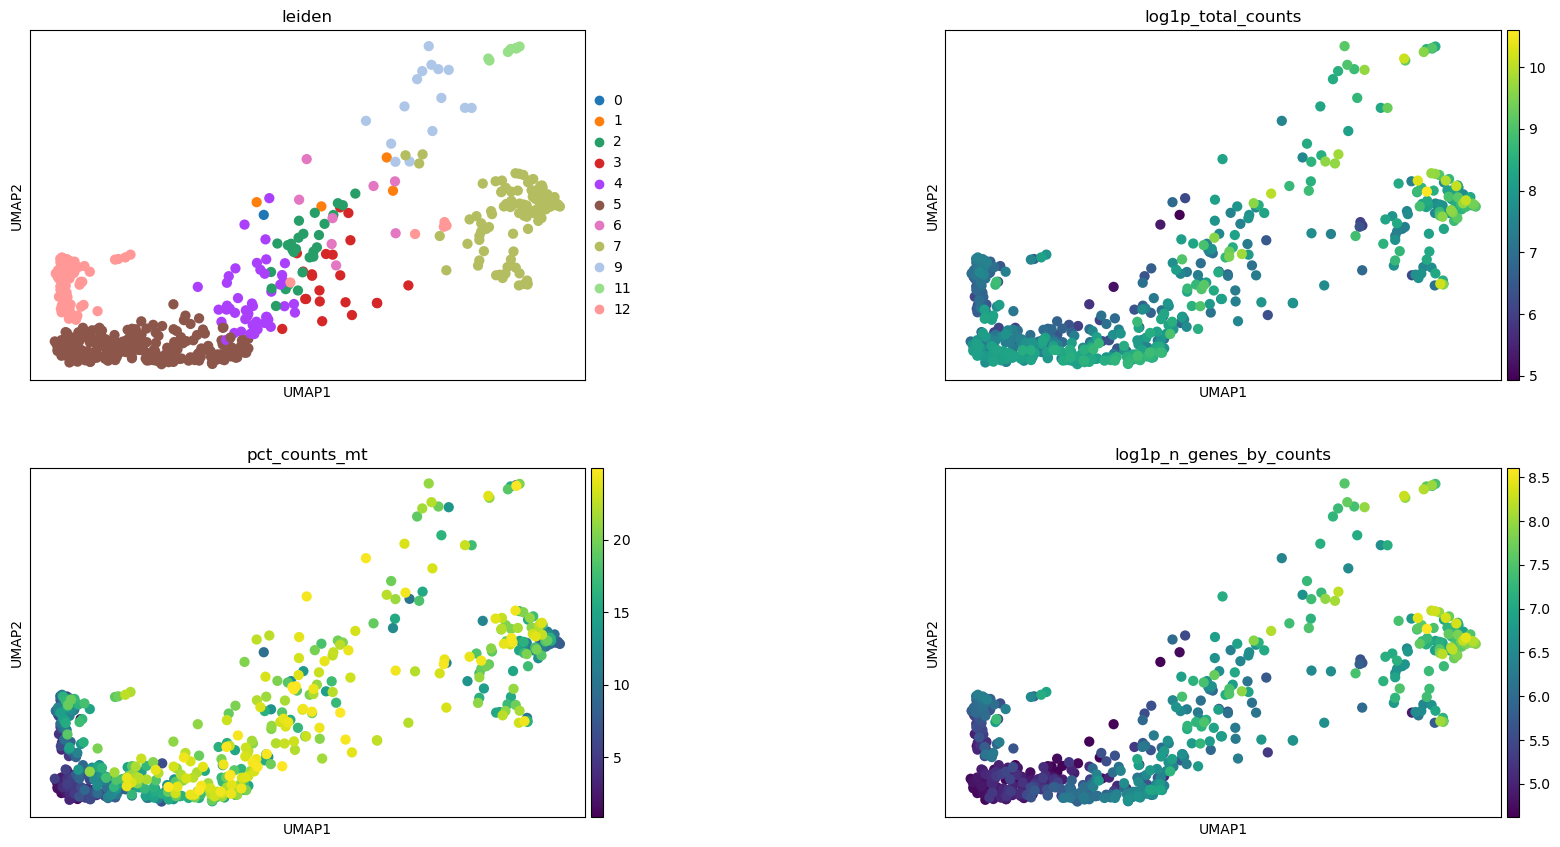

In [94]:
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

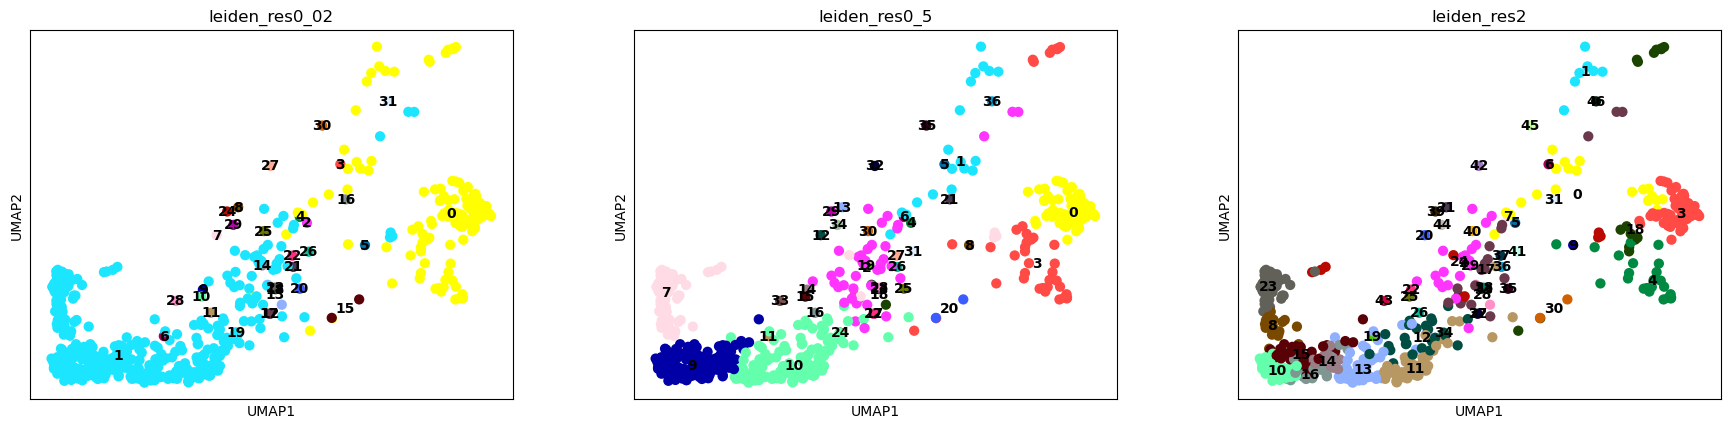

In [103]:
sc.pl.umap(
    adata,
    color=["leiden_res0_02", "leiden_res0_5", "leiden_res2"],
    legend_loc="on data",
)

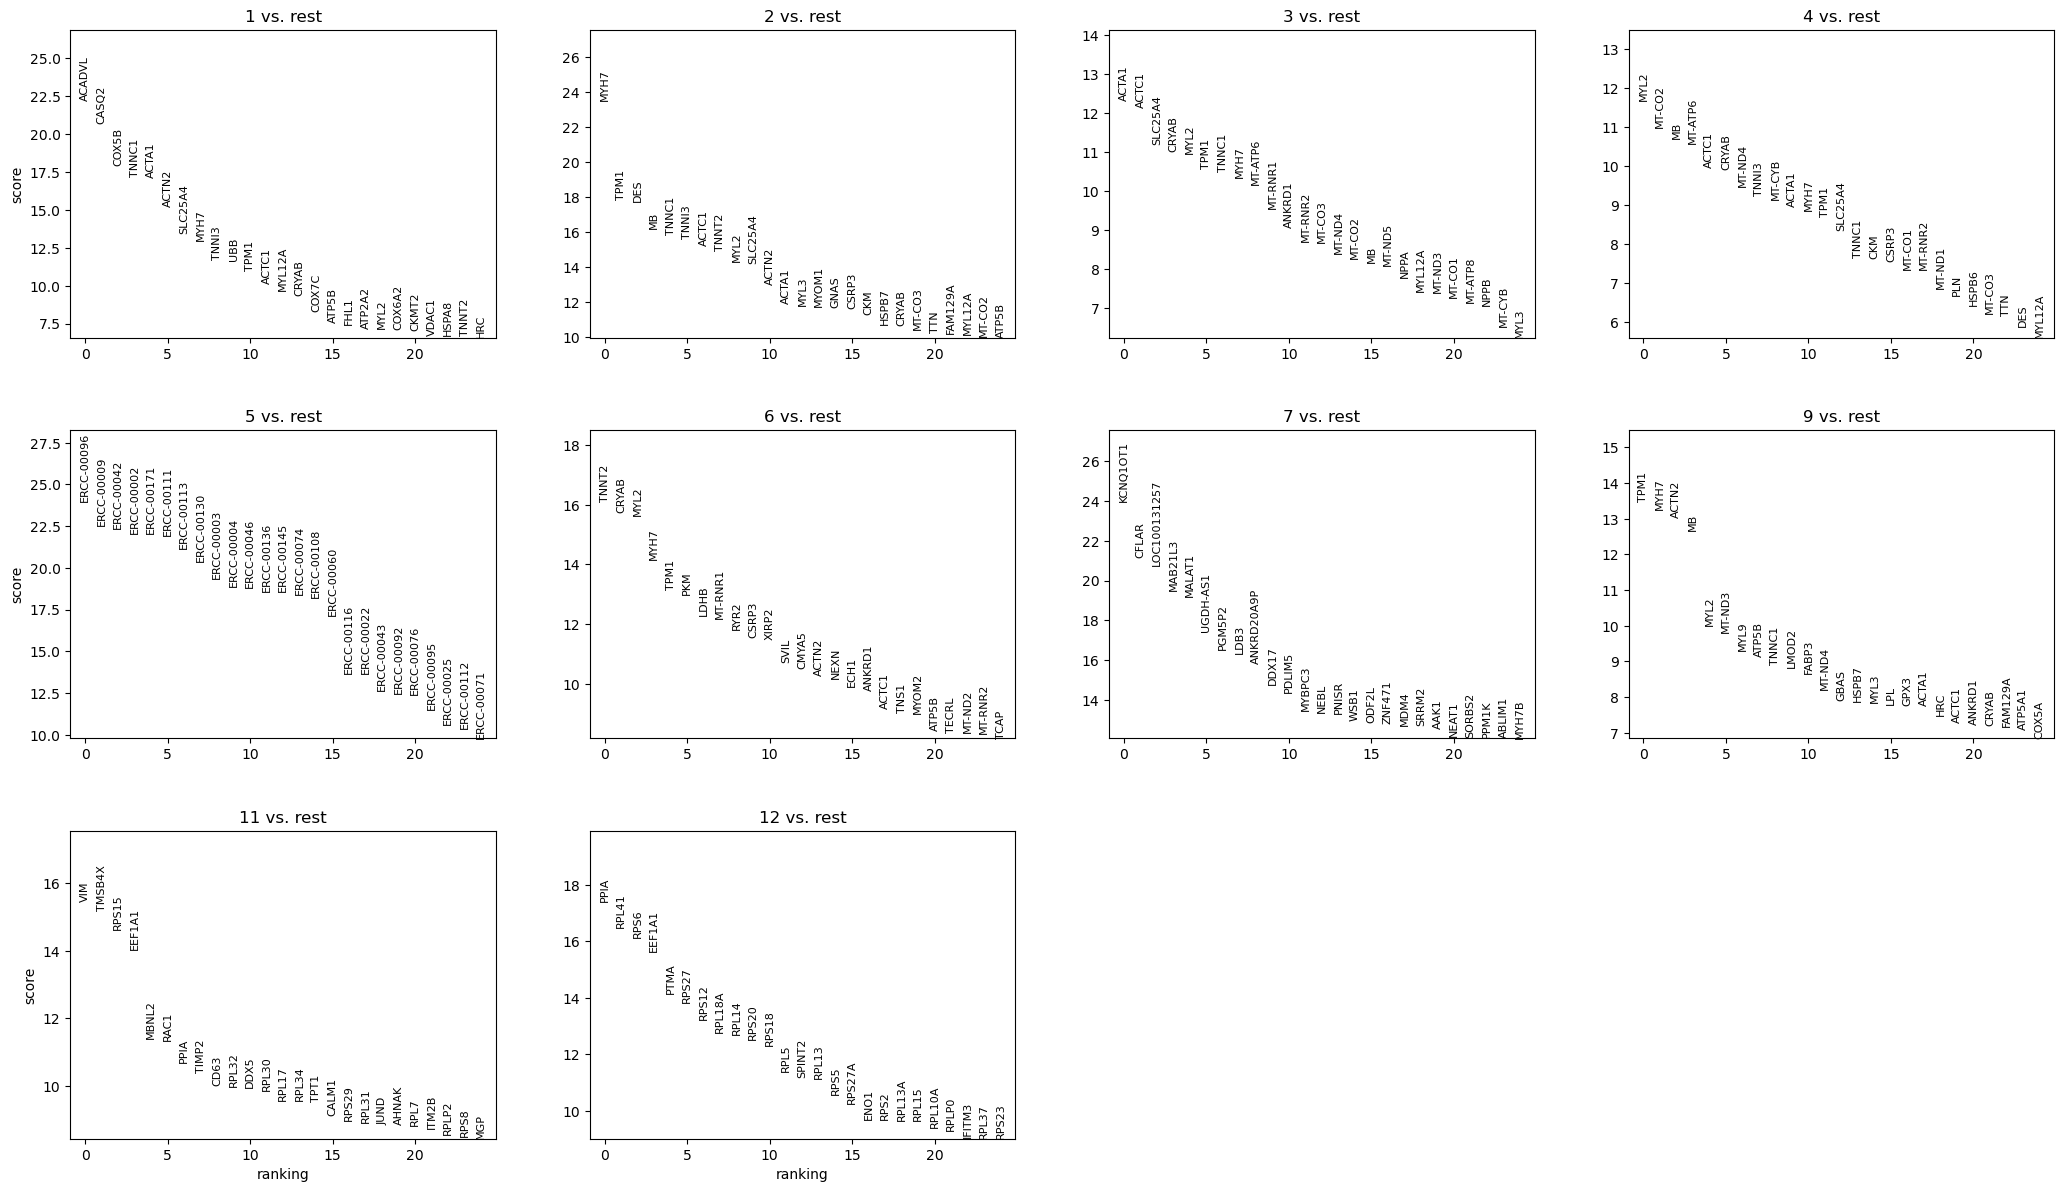

In [109]:
# Get cell counts per cluster
cluster_counts = adata.obs['leiden'].value_counts()

# Identify clusters with more than 3 cells
valid_clusters = cluster_counts[cluster_counts > 3].index.tolist()

# Subset the data to only valid clusters
adata_valid = adata[adata.obs['leiden'].isin(valid_clusters)].copy()

# Now run DE
sc.tl.rank_genes_groups(adata_valid, groupby='leiden', method='t-test')
sc.pl.rank_genes_groups(adata_valid, n_genes=25, sharey=False)


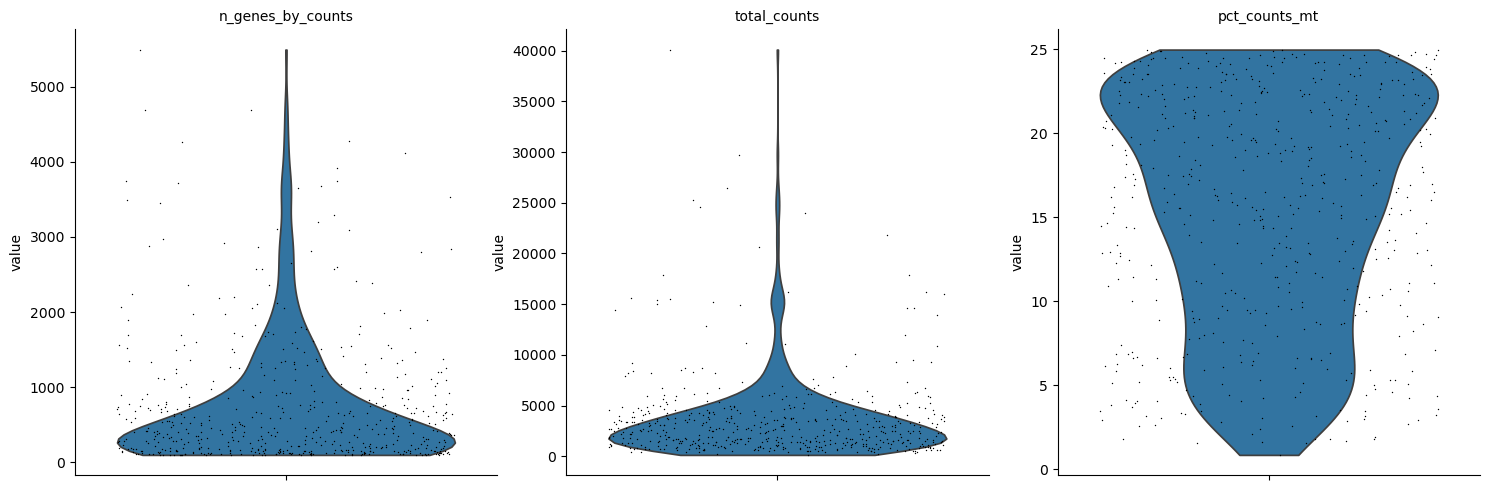

In [98]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [67]:
print(adata.var.head())

                  mt   ribo     hb  n_cells_by_counts  mean_counts  \
GENEID         False  False  False               6144   192.500000   
A2M__chr12     False  False  False               1000     0.311507   
A4GALT__chr22  False  False  False                390     0.079591   
AAAS__chr12    False  False  False                255     0.056480   
AACS__chr12    False  False  False                 83     0.014486   

               log1p_mean_counts  pct_dropout_by_counts  total_counts  \
GENEID                  5.265278               0.000000  1.182720e+06   
A2M__chr12              0.271177              83.723958  1.913897e+03   
A4GALT__chr22           0.076582              93.652344  4.890050e+02   
AAAS__chr12             0.054943              95.849609  3.470143e+02   
AACS__chr12             0.014382              98.649089  8.900037e+01   

               log1p_total_counts  n_cells  highly_variable     means  \
GENEID                  13.983328     4178             True  5.5590

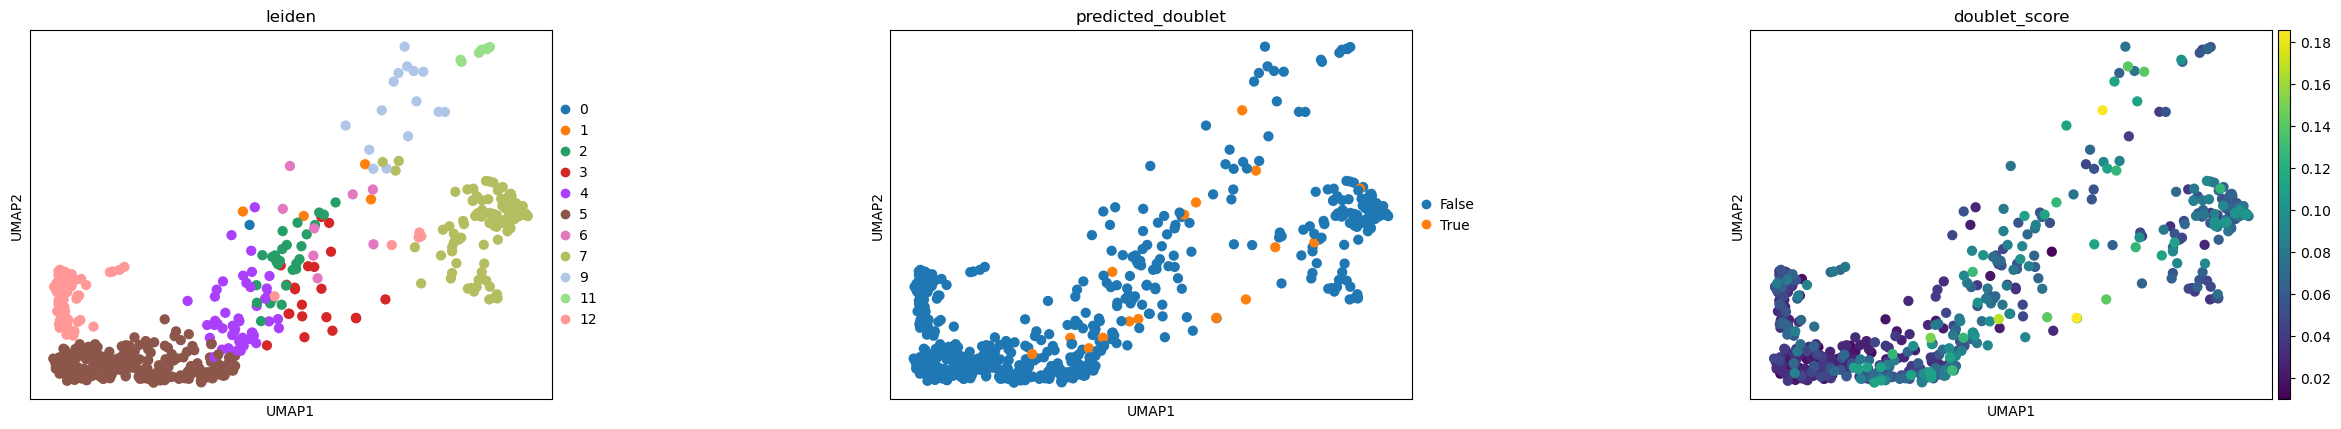

In [110]:
adata.obs["predicted_doublet"] = adata.obs["predicted_doublet"].astype("category")
sc.pl.umap(
    adata,
    color=["leiden", "predicted_doublet", "doublet_score"],
    # increase horizontal space between panels
    wspace=0.5,
)

In [111]:
adata = adata[~adata.obs["predicted_doublet"].to_numpy()].copy()

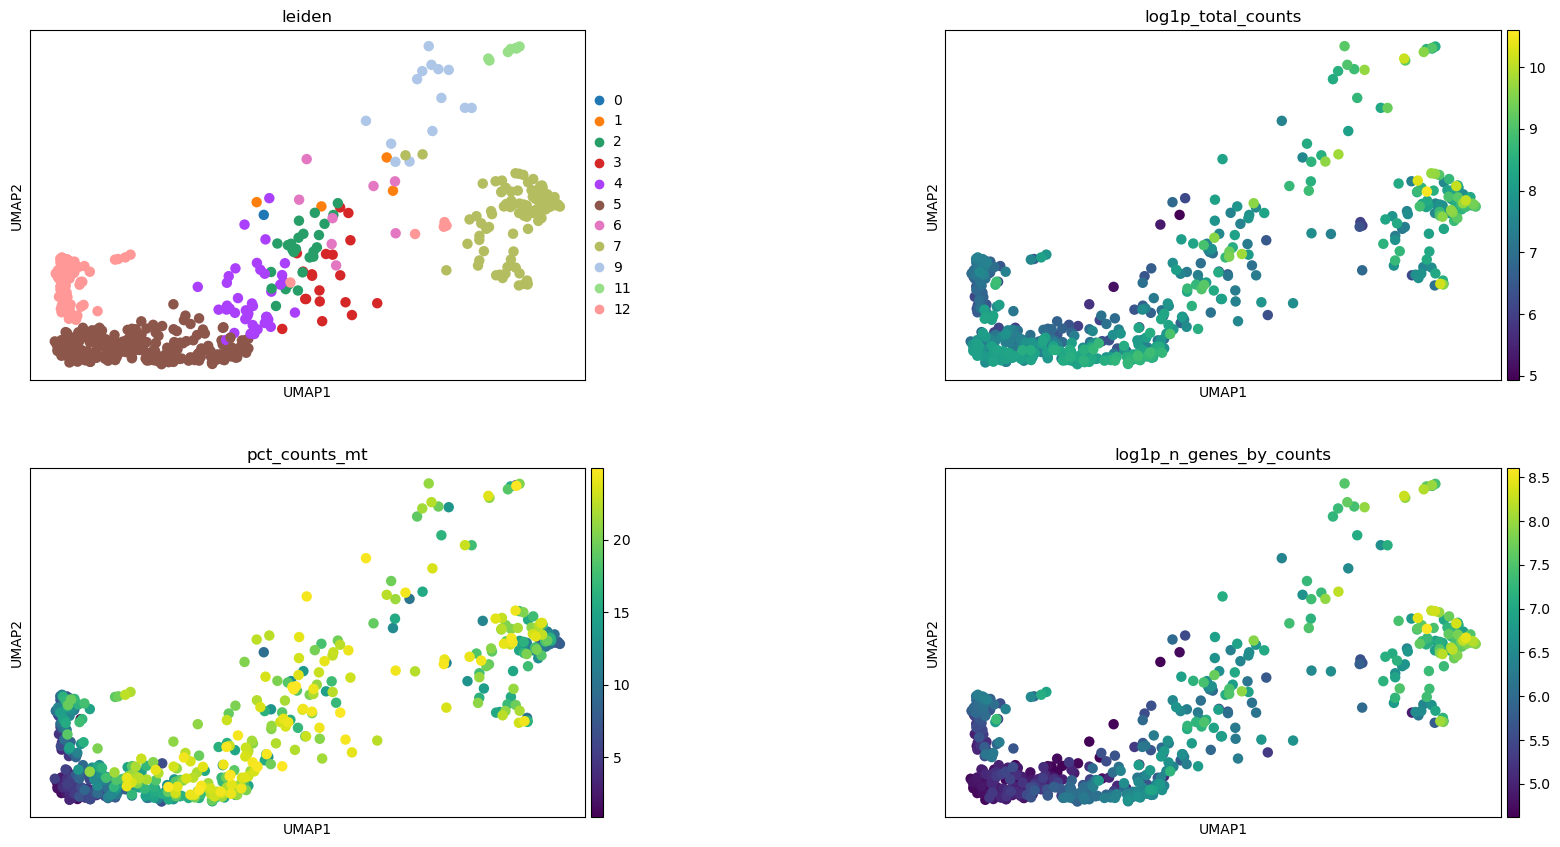

In [112]:
sc.pl.umap(
    adata, color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"], wspace=0.5, ncols=2
)

In [113]:
import celltypist as ct
import decoupler as dc
sc.tl.leiden(adata, flavor="igraph", key_added="leiden_res0_02", resolution=0.02)
sc.tl.leiden(adata, flavor="igraph", key_added="leiden_res0_5", resolution=0.5)
sc.tl.leiden(adata, flavor="igraph", key_added="leiden_res2", resolution=2)

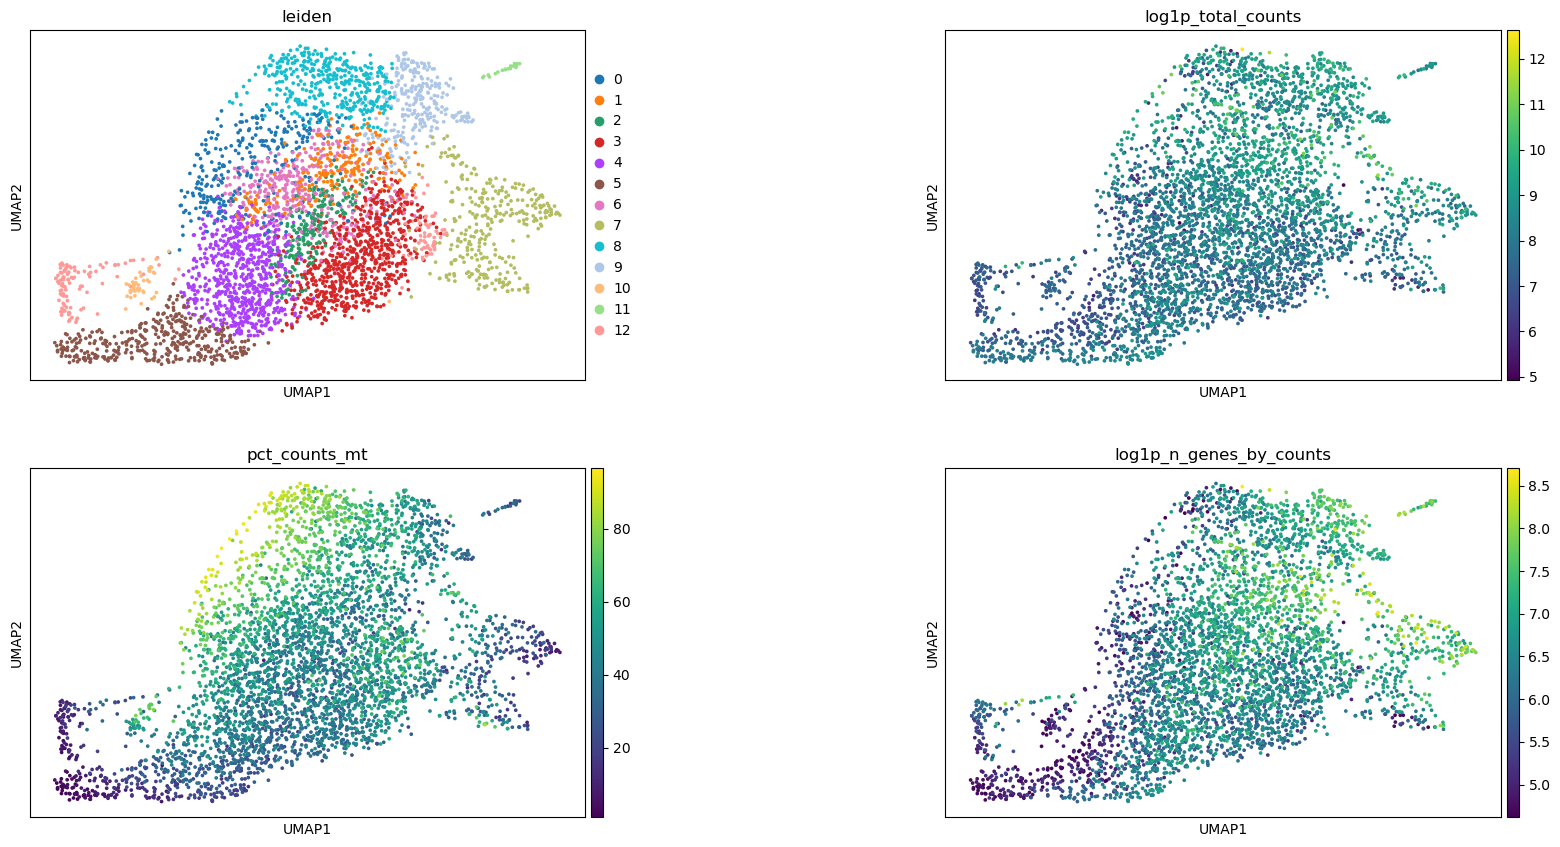

In [92]:
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

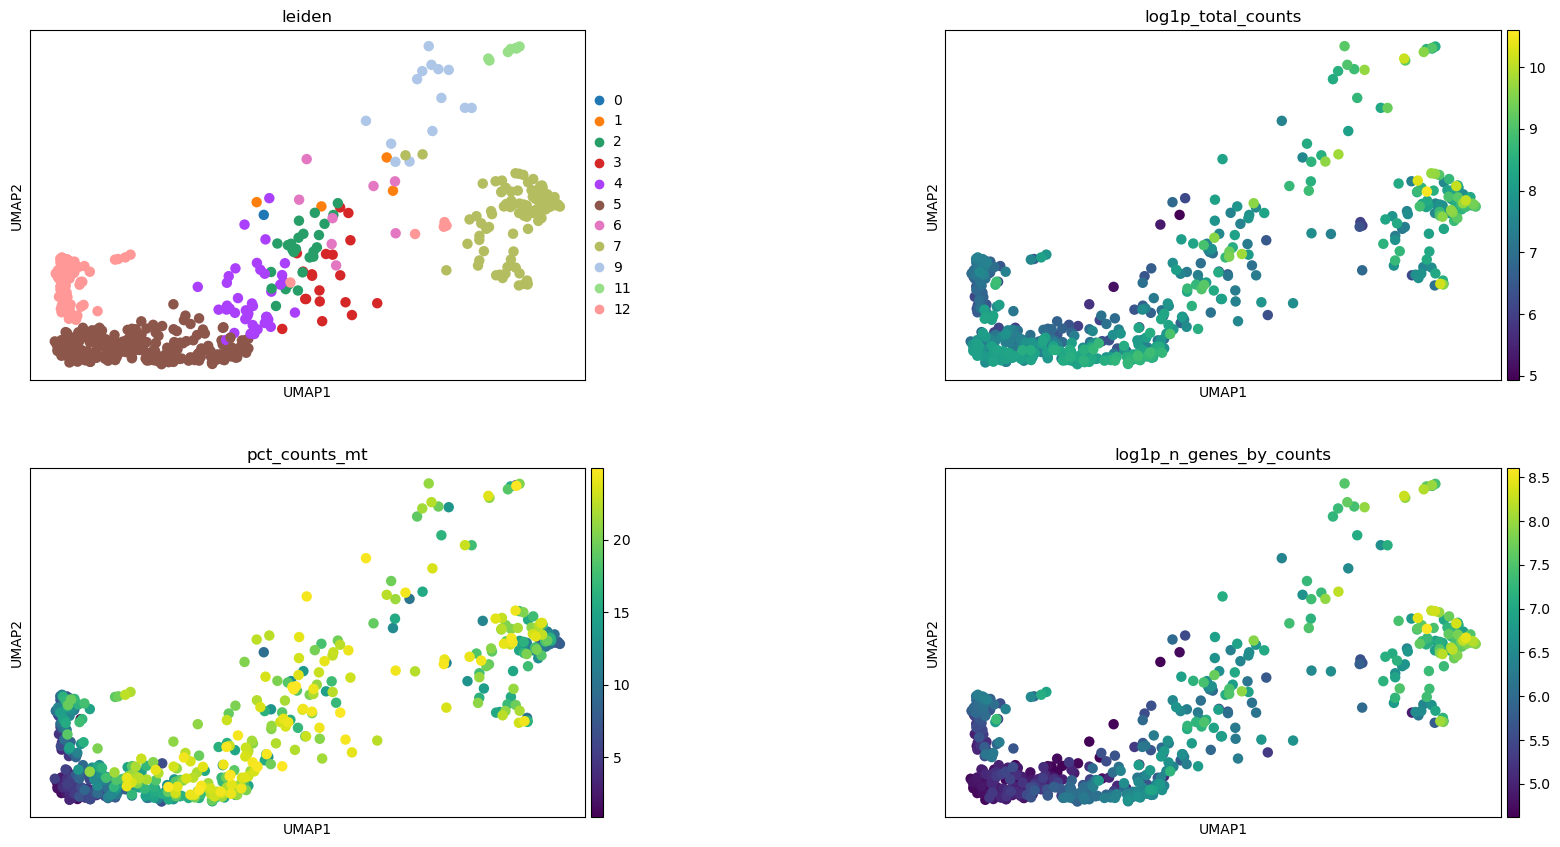

In [114]:
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

In [115]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    # Note HBM and GYPA are negative markers
    "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # Note IGHD and IGHM are negative markers
    "B cells": ["MS4A1", "ITGB1", "COL4A4", "PRDM1", "IRF4", "PAX5", "BCL11A", "BLK", "IGHD", "IGHM"],
    "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],  # Note PAX5 is a negative marker
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}

def group_max(adata: sc.AnnData, groupby: str) -> str:
    import pandas as pd

    agg = sc.get.aggregate(adata, by=groupby, func="mean")
    return pd.Series(agg.layers["mean"].sum(1), agg.obs[groupby]).idxmax()

In [116]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res0_02")

KeyError: "Could not find keys [np.str_('BLK'), np.str_('CCL5'), np.str_('CCR7'), np.str_('CD14'), np.str_('CD247'), np.str_('CD4'), np.str_('CD8A'), np.str_('CD8B'), np.str_('CLEC10A'), np.str_('COL4A4'), np.str_('COTL1'), np.str_('FCER1A'), np.str_('FCER1G'), np.str_('FCGR3A'), np.str_('FCN1'), np.str_('FCRL1'), np.str_('GNLY'), np.str_('GYPA'), np.str_('GZMA'), np.str_('GZMB'), np.str_('GZMH'), np.str_('GZMK'), np.str_('HBA1'), np.str_('HBB'), np.str_('HBM'), np.str_('IGHD'), np.str_('IGHM'), np.str_('IGKC'), np.str_('IL3RA'), np.str_('IL4R'), np.str_('IL7R'), np.str_('IRF4'), np.str_('JCHAIN'), np.str_('KLRG1'), np.str_('LEF1'), np.str_('LYN'), np.str_('LYZ'), np.str_('MKI67'), np.str_('MS4A1'), np.str_('MZB1'), np.str_('NKG7'), np.str_('PAX5'), np.str_('PLCG2'), np.str_('PRDM1'), np.str_('TCF7'), np.str_('TRBC2'), np.str_('TYROBP')] in columns of `adata.obs` or in adata.var_names."

In [120]:
adata.var_names = adata.var.index

In [121]:
adata.var_names

Index(['A2M', 'A4GALT', 'AAAS', 'AACS', 'AAGAB', 'AAK1', 'AAMDC', 'AAMP',
       'AAR2', 'AARS2',
       ...
       'ZSWIM1', 'ZSWIM6', 'ZSWIM7', 'ZSWIM8', 'ZW10', 'ZWILCH', 'ZXDC',
       'ZYG11B', 'ZYX', 'ZZEF1'],
      dtype='object', name='original_id', length=8200)

In [122]:
sc.pl.dotplot(adata, marker_genes, groupby="leiden_res0_02")

KeyError: "Could not find keys [np.str_('BLK'), np.str_('CCL5'), np.str_('CCR7'), np.str_('CD14'), np.str_('CD247'), np.str_('CD4'), np.str_('CD8A'), np.str_('CD8B'), np.str_('CLEC10A'), np.str_('COL4A4'), np.str_('COTL1'), np.str_('FCER1A'), np.str_('FCER1G'), np.str_('FCGR3A'), np.str_('FCN1'), np.str_('FCRL1'), np.str_('GNLY'), np.str_('GYPA'), np.str_('GZMA'), np.str_('GZMB'), np.str_('GZMH'), np.str_('GZMK'), np.str_('HBA1'), np.str_('HBB'), np.str_('HBM'), np.str_('IGHD'), np.str_('IGHM'), np.str_('IGKC'), np.str_('IL3RA'), np.str_('IL4R'), np.str_('IL7R'), np.str_('IRF4'), np.str_('JCHAIN'), np.str_('KLRG1'), np.str_('LEF1'), np.str_('LYN'), np.str_('LYZ'), np.str_('MKI67'), np.str_('MS4A1'), np.str_('MZB1'), np.str_('NKG7'), np.str_('PAX5'), np.str_('PLCG2'), np.str_('PRDM1'), np.str_('TCF7'), np.str_('TRBC2'), np.str_('TYROBP')] in columns of `adata.obs` or in adata.var_names."

In [123]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    "ID2-hi myeloid prog": [
        "CD14",
        "ID2",
        "VCAN",
        "S100A9",
        "CLEC12A",
        "KLF4",
        "PLAUR",
    ],
    "cDC1": ["CLEC9A", "CADM1"],
    "cDC2": [
        "CST3",
        "COTL1",
        "LYZ",
        "DMXL2",
        "CLEC10A",
        "FCER1A",
    ],  # Note: DMXL2 should be negative
    "Normoblast": ["SLC4A1", "SLC25A37", "HBB", "HBA2", "HBA1", "TFRC"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    "Proerythroblast": [
        "CDK6",
        "SYNGR1",
        "HBM",
        "GYPA",
    ],  # Note HBM and GYPA are negative markers
    "NK": ["GNLY", "NKG7", "CD247", "GRIK4", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Lymph prog": [
        "VPREB1",
        "MME",
        "EBF1",
        "SSBP2",
        "BACH2",
        "CD79B",
        "IGHM",
        "PAX5",
        "PRKCE",
        "DNTT",
        "IGLL1",
    ],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    "B1 B": [
        "MS4A1",
        "SSPN",
        "ITGB1",
        "EPHA4",
        "COL4A4",
        "PRDM1",
        "IRF4",
        "CD38",
        "XBP1",
        "PAX5",
        "BCL11A",
        "BLK",
        "IGHD",
        "IGHM",
        "ZNF215",
    ],  # Note IGHD and IGHM are negative markers
    "Transitional B": ["MME", "CD38", "CD24", "ACSM3", "MSI2"],
    "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    "Plasmablast": ["XBP1", "RF4", "PRDM1", "PAX5"],  # Note PAX5 is a negative marker
    "CD4+ T activated": ["CD4", "IL7R", "TRBC2", "ITGB1"],
    "CD4+ T naive": ["CD4", "IL7R", "TRBC2", "CCR7"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T activation": ["CD69", "CD38"],  # CD69 much better marker!
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
    "G/M prog": ["MPO", "BCL2", "KCNQ5", "CSF3R"],
    "HSC": ["NRIP1", "MECOM", "PROM1", "NKAIN2", "CD34"],
    "MK/E prog": [
        "ZNF385D",
        "ITGA2B",
        "RYR3",
        "PLCB1",
    ],  # Note PLCB1 is a negative marker
}

In [125]:
marker_genes_in_data = {}
for ct, markers in marker_genes.items():
    markers_found = []
    for marker in markers:
        if marker in adata.var.index:
            markers_found.append(marker)
    marker_genes_in_data[ct] = markers_found

In [1]:
adata.layers["counts"] = adata.X
adata.X = adata.layers["scran_normalization"]

NameError: name 'adata' is not defined

In [127]:
adata.layers["scran_normalization"] = loaded_matrix
adata.X = adata.layers["scran_normalization"]

AnnData object with n_obs × n_vars = 531 × 8200
    obs: 'Sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden', 'leiden_res0_02', 'leiden_res0_5', 'leiden_res2'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'scrublet', 'log1p', 'hvg', 'pca', 'Sample_colors', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'predicted_doublet_colors', 'rank_ge

In [14]:
adata.obs

,Sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb
001,Patient3Plate3,57,4.060443,399.82,5.993512,98.249212,100.000000,100.000000,100.0,65.06,4.190563,16.272323,3.0,1.386294,0.750338,0.0,0.0,0.0
002,Patient3Plate3,60,4.110874,341.77,5.837060,97.074056,100.000000,100.000000,100.0,126.23,4.845996,36.934196,0.0,0.000000,0.000000,0.0,0.0,0.0
003,Patient3Plate3,47,3.871201,363.64,5.898911,100.000000,100.000000,100.000000,100.0,51.03,3.951820,14.033110,1.0,0.693147,0.274997,0.0,0.0,0.0
004,Patient3Plate3,368,5.910797,4199.52,8.342964,90.665600,93.189698,95.999543,100.0,3416.51,8.136667,81.354774,10.0,2.397895,0.238122,0.0,0.0,0.0
005,Patient3Plate3,276,5.624018,1231.06,7.116443,77.742758,85.703378,93.826458,100.0,579.97,6.364699,47.111432,6.0,1.945910,0.487385,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380-15,Patient5Plate2,172,5.153292,592.91,6.386728,79.423521,87.856504,100.000000,100.0,386.91,5.960773,65.256110,10.0,2.397895,1.686597,0.0,0.0,0.0
381-15,Patient5Plate2,28,3.367296,108.10,4.692265,100.000000,100.000000,100.000000,100.0,93.10,4.544358,86.123959,0.0,0.000000,0.000000,0.0,0.0,0.0
382-15,Patient5Plate2,10,2.397895,13.00,2.639057,100.000000,100.000000,100.000000,100.0,9.00,2.302585,69.230769,0.0,0.000000,0.000000,0.0,0.0,0.0
383-15,Patient5Plate2,178,5.187386,849.89,6.746283,83.409618,90.822342,100.000000,100.0,532.74,6.279909,62.683406,3.0,1.386294,0.352987,0.0,0.0,0.0


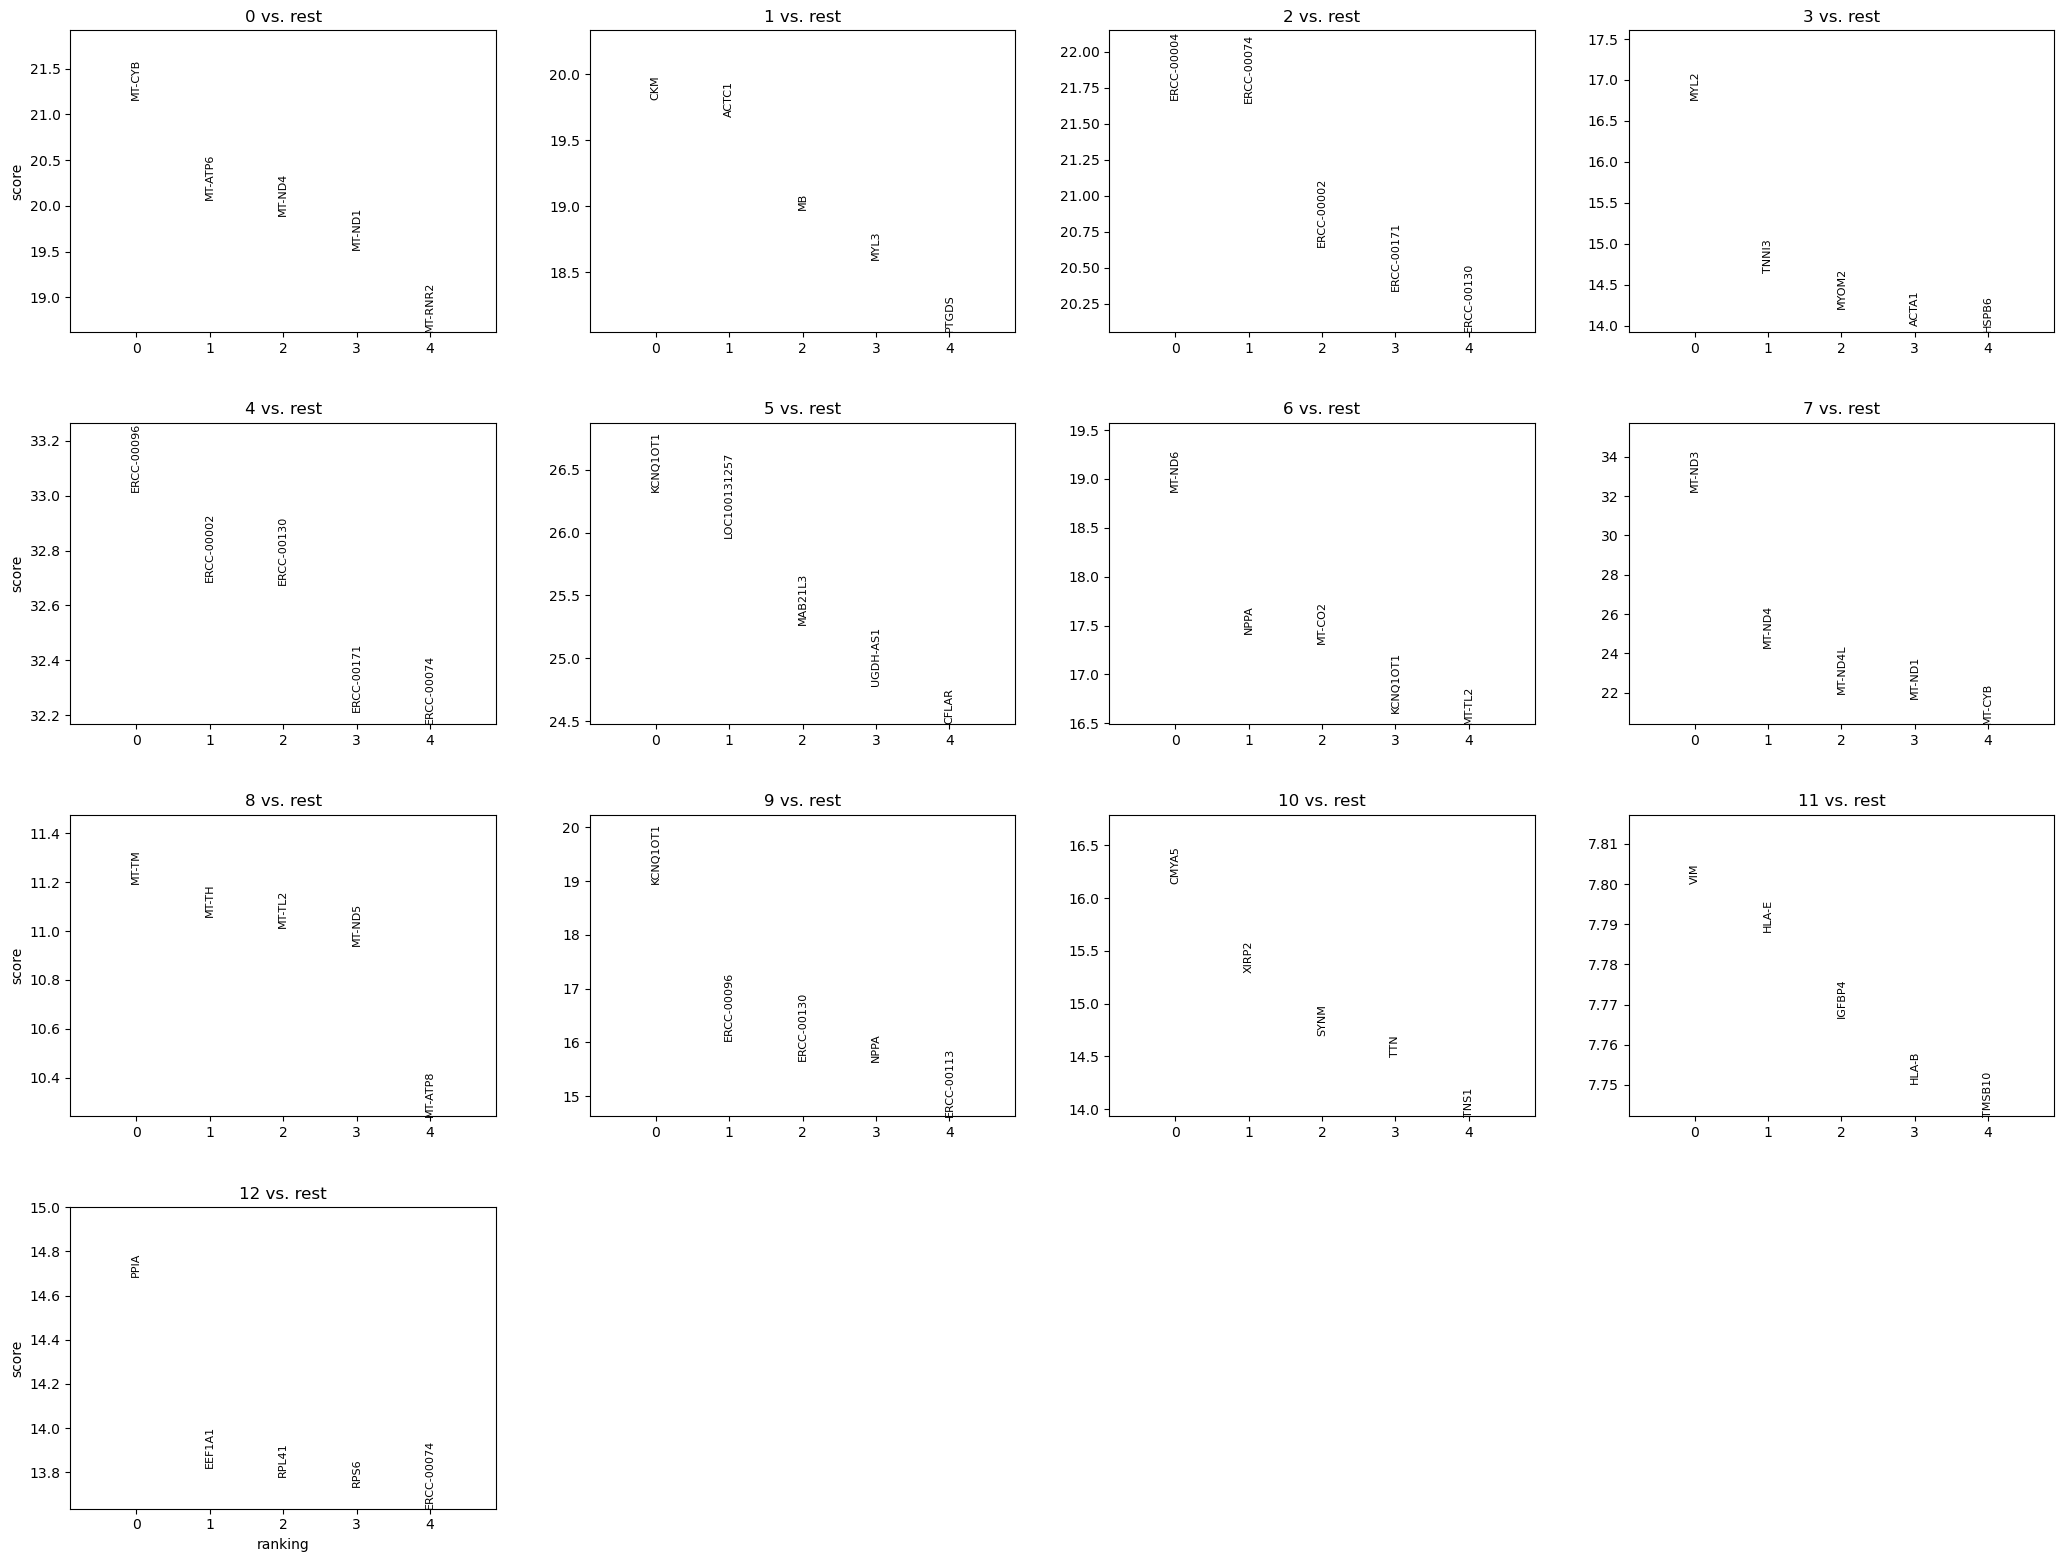

In [23]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False)